# Análise Exploratória de Dados (AED)

In [60]:
# Configuração iniciais
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configurações estéticas profissionais
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.unicode_minus"] = False
print("✓ Ambiente configurado com sucesso!")

✓ Ambiente configurado com sucesso!


In [61]:
# Carregar os dados
BASE_DIR = Path(os.getcwd()).resolve()
if BASE_DIR.name == 'notebooks':
    BASE_DIR = BASE_DIR.parent

RAW_DATA_PATH = BASE_DIR / "data" / "raw" / "desafio_nps_fase_1.csv"

df = pd.read_csv(RAW_DATA_PATH)
print(f"✓ Linhas: {df.shape[0]} | Colunas: {df.shape[1]}")
df.head()

✓ Linhas: 2500 | Colunas: 19


,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


## Visão geral e Qualidade dos dados

In [62]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   str    
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_contacts  2500 non-null   int64  
 14  res

In [63]:
# Verifica valores nulos
df.isnull().sum()

customer_id                  0
customer_age                 0
customer_region              0
customer_tenure_months       0
order_id                     0
order_value                  0
items_quantity               0
discount_value               0
payment_installments         0
delivery_time_days           0
delivery_delay_days          0
freight_value                0
delivery_attempts            0
customer_service_contacts    0
resolution_time_days         0
nps_score                    0
repeat_purchase_30d          0
complaints_count             0
csat_internal_score          0
dtype: int64

In [64]:
# Verifica valores unicos para as variaveis
for i in df.columns[0:22].to_list():
    print(i, ':', len(df[i].astype(str).value_counts())) 

customer_id : 2500
customer_age : 52
customer_region : 5
customer_tenure_months : 119
order_id : 2500
order_value : 2457
items_quantity : 6
discount_value : 2050
payment_installments : 11
delivery_time_days : 13
delivery_delay_days : 9
freight_value : 1897
delivery_attempts : 3
customer_service_contacts : 8
resolution_time_days : 12
nps_score : 101
repeat_purchase_30d : 2
complaints_count : 12
csat_internal_score : 98


In [65]:
# visualizar medidas estatísticas de cada variável
df.describe()

,customer_id,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,2500.00000,2500.000000,2500.000000,2500.00000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,1250.50000,43.396000,61.322400,51250.50000,434.259740,3.470800,29.745620,6.004000,8.022000,2.187200,38.217016,2.005600,1.519600,5.485600,4.378600,0.087200,4.150400,2.941600
std,721.83216,14.888487,34.478729,721.83216,289.772497,1.687331,29.225603,3.159743,3.770411,1.454442,12.076074,0.815497,1.231512,3.458002,2.510229,0.282184,1.784223,2.378957
min,1.00000,18.000000,1.000000,50001.00000,7.760000,1.000000,0.020000,1.000000,2.000000,0.000000,2.620000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,625.75000,31.000000,31.000000,50625.75000,220.245000,2.000000,8.885000,3.000000,5.000000,1.000000,29.927500,1.000000,1.000000,2.000000,2.600000,0.000000,3.000000,0.700000
50%,1250.50000,43.000000,62.000000,51250.50000,375.515000,3.000000,20.935000,6.000000,8.000000,2.000000,38.500000,2.000000,1.000000,6.000000,4.400000,0.000000,4.000000,2.800000
75%,1875.25000,56.000000,91.000000,51875.25000,577.290000,5.000000,40.832500,9.000000,11.000000,3.000000,46.270000,3.000000,2.000000,8.000000,6.100000,0.000000,5.000000,4.800000
max,2500.00000,69.000000,119.000000,52500.00000,1983.810000,6.000000,230.330000,11.000000,14.000000,8.000000,76.130000,3.000000,7.000000,11.000000,10.000000,1.000000,11.000000,10.000000


### Verificação de Outliers e tratamento

In [66]:
# Verificação de outliers por variável numérica
import numpy as np

numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
exclude_cols = ["customer_id", "order_id", "nps_score", "repeat_purchase_30d", "is_detractor"]
numeric_cols = [col for col in numeric_cols if col not in exclude_cols]

print("Colunas numéricas avaliadas:", numeric_cols)

for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    print(f"\n{col}:")
    print(f"  Q1={q1:.2f}, Q3={q3:.2f}, IQR={iqr:.2f}")
    print(f"  Limites: [{lower:.2f}, {upper:.2f}]")
    print(f"  Outliers: {len(outliers)}")

Colunas numéricas avaliadas: ['customer_age', 'customer_tenure_months', 'order_value', 'items_quantity', 'discount_value', 'payment_installments', 'delivery_time_days', 'delivery_delay_days', 'freight_value', 'delivery_attempts', 'customer_service_contacts', 'resolution_time_days', 'complaints_count', 'csat_internal_score']

customer_age:
  Q1=31.00, Q3=56.00, IQR=25.00
  Limites: [-6.50, 93.50]
  Outliers: 0

customer_tenure_months:
  Q1=31.00, Q3=91.00, IQR=60.00
  Limites: [-59.00, 181.00]
  Outliers: 0

order_value:
  Q1=220.25, Q3=577.29, IQR=357.04
  Limites: [-315.32, 1112.86]
  Outliers: 84

items_quantity:
  Q1=2.00, Q3=5.00, IQR=3.00
  Limites: [-2.50, 9.50]
  Outliers: 0

discount_value:
  Q1=8.88, Q3=40.83, IQR=31.95
  Limites: [-39.04, 88.75]
  Outliers: 125

payment_installments:
  Q1=3.00, Q3=9.00, IQR=6.00
  Limites: [-6.00, 18.00]
  Outliers: 0

delivery_time_days:
  Q1=5.00, Q3=11.00, IQR=6.00
  Limites: [-4.00, 20.00]
  Outliers: 0

delivery_delay_days:
  Q1=1.00, Q3

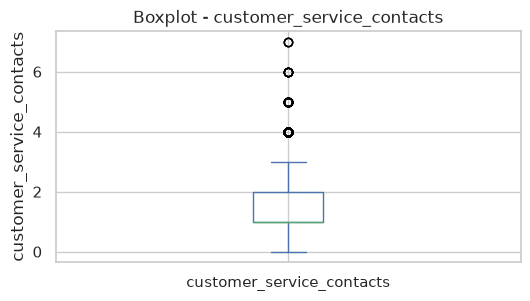

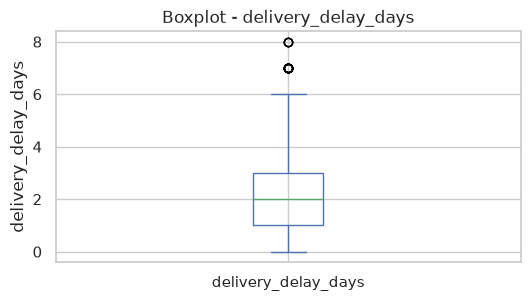

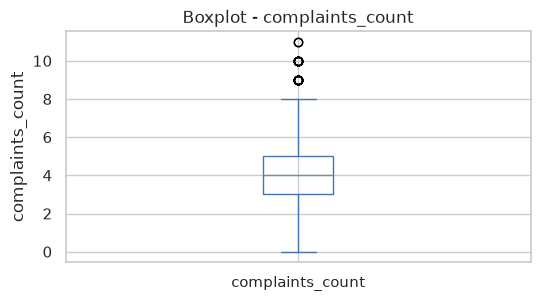

In [67]:
# Outliers mais relevantes
cols_focus = ["customer_service_contacts", "delivery_delay_days", "complaints_count"]

# Boxplot para as 3 variáveis
for col in cols_focus:
    plt.figure(figsize=(6, 3))
    df[col].plot.box()
    plt.title(f"Boxplot - {col}")
    plt.ylabel(col)
    plt.show()

customer_service_contacts:
  Limite inferior: -0.50
  Limite superior: 3.50
  Máximo após winsorização: 3.50
  Mínimo após winsorização: 0.00
delivery_delay_days:
  Limite inferior: -2.00
  Limite superior: 6.00
  Máximo após winsorização: 6.00
  Mínimo após winsorização: 0.00
complaints_count:
  Limite inferior: 0.00
  Limite superior: 8.00
  Máximo após winsorização: 8.00
  Mínimo após winsorização: 0.00


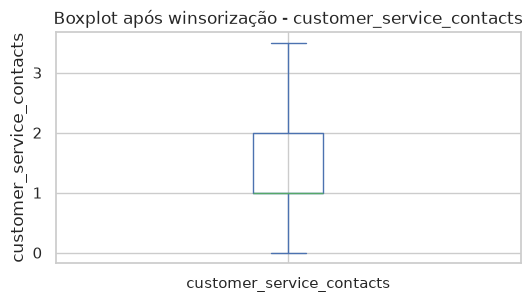

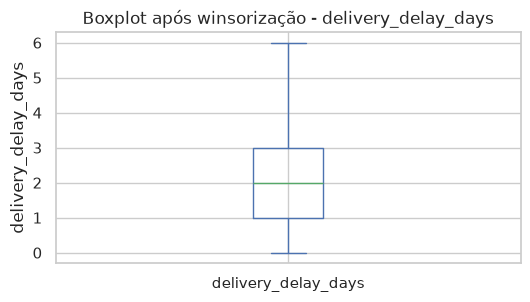

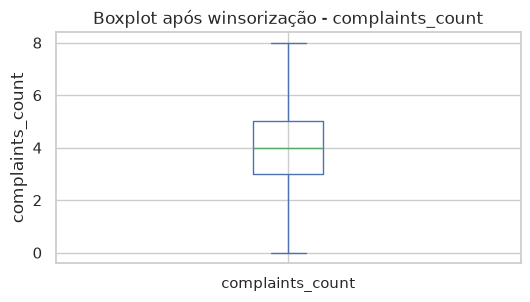

In [68]:
# Winsorização das 3 colunas com outliers relevantes
cols_to_winsorize = ["customer_service_contacts", "delivery_delay_days", "complaints_count"]

for col in cols_to_winsorize:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

    print(f"{col}:")
    print(f"  Limite inferior: {lower_bound:.2f}")
    print(f"  Limite superior: {upper_bound:.2f}")
    print(f"  Máximo após winsorização: {df[col].max():.2f}")
    print(f"  Mínimo após winsorização: {df[col].min():.2f}")

for col in cols_to_winsorize:
    plt.figure(figsize=(6, 3))
    df[col].plot.box()
    plt.title(f"Boxplot após winsorização - {col}")
    plt.ylabel(col)
    plt.show()

### Análise do NPS

In [69]:
# Analise do NPS (nps_score)
total_customers = len(df)
promoters = df[df['nps_score'] >= 9].shape[0]
neutrals = df[(df['nps_score'] >= 7) & (df['nps_score'] <= 8)].shape[0]
detractors = df[df['nps_score'] <= 6].shape[0]

pct_promoters = promoters / total_customers * 100
pct_neutrals = neutrals / total_customers * 100
pct_detractors = detractors / total_customers * 100
nps_value = pct_promoters - pct_detractors
mean_sat = df['nps_score'].mean()

print("=== MÉTRICAS GERAIS DE SATISFAÇÃO ===")
print(f"-> Total de Transações Avaliadas: {total_customers}")
print(f"-> Promotores (Notas 9-10): {promoters} ({pct_promoters:.2f}%)")
print(f"-> Neutros (Notas 7-8): {neutrals} ({pct_neutrals:.2f}%)")
print(f"-> Detratores (Notas 0-6): {detractors} ({pct_detractors:.2f}%)")
print(f"-> NPS Tradicional Amostral: {nps_value:.2f}%")
print(f"-> Nota Média de Satisfação: {mean_sat:.3f}")

=== MÉTRICAS GERAIS DE SATISFAÇÃO ===
-> Total de Transações Avaliadas: 2500
-> Promotores (Notas 9-10): 110 (4.40%)
-> Neutros (Notas 7-8): 190 (7.60%)
-> Detratores (Notas 0-6): 1851 (74.04%)
-> NPS Tradicional Amostral: -69.64%
-> Nota Média de Satisfação: 4.379


### Análise da variável alvo (Target)

In [70]:
# Agrupar o NPS entre Detratores e não Detratores
df["is_detractor"] = (df["nps_score"] <= 6).astype(int)

contagem = df["is_detractor"].value_counts().sort_index()
contagem = contagem.rename(index={1: "detrator", 0: "nao_detrator"})

print(contagem)

is_detractor
nao_detrator     649
detrator        1851
Name: count, dtype: int64


## Analise Estatística

### Teste de Normalidade
Para provar estatisticamente que a nota de NPS (`nps_score`) não se comporta segundo a distribuição normal padrão de Gauss, aplicaremos o teste de normalidade **Shapiro-Wilk**. A hipótese nula ($H_0$) do teste é de que os dados seguem uma distribuição normal. Se $p < 0.05$, rejeitamos a normalidade.

=== TESTE DE NORMALIDADE DE SHAPIRO-WILK ===
-> Estatística do Teste: 0.9817
-> p-valor do Teste: 2.1430e-17
✓ Conclusão: p-valor < 0.05. Rejeitamos a hipótese nula de normalidade com 95% de confiança!
  Isto prova que as notas de satisfação NÃO são distribuídas de forma normal, justificando testes não paramétricos.


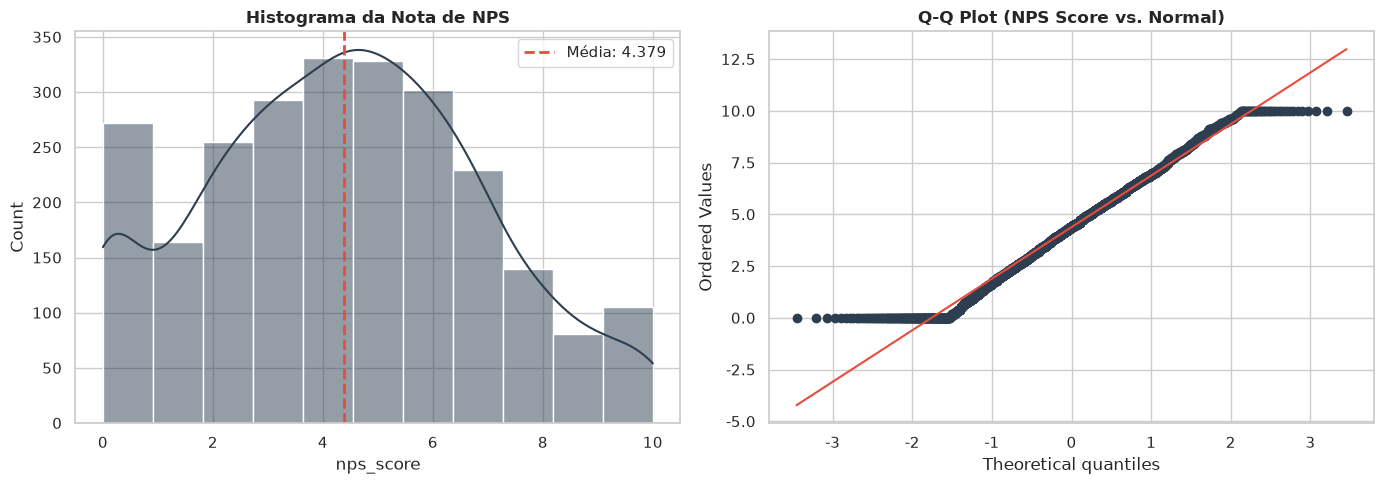

In [71]:
# Teste de Shapiro-Wilk e Visualização da Distribuição
stat_shapiro, p_shapiro = stats.shapiro(df['nps_score'])
print("=== TESTE DE NORMALIDADE DE SHAPIRO-WILK ===")
print(f"-> Estatística do Teste: {stat_shapiro:.4f}")
print(f"-> p-valor do Teste: {p_shapiro:.4e}")

if p_shapiro < 0.05:
    print("✓ Conclusão: p-valor < 0.05. Rejeitamos a hipótese nula de normalidade com 95% de confiança!")
    print("  Isto prova que as notas de satisfação NÃO são distribuídas de forma normal, justificando testes não paramétricos.")
else:
    print("-> Não foi possível rejeitar a hipótese de normalidade.")

# Plot interativo da Distribuição e Q-Q Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['nps_score'], bins=11, kde=True, ax=axes[0], color="#2c3e50")
axes[0].axvline(mean_sat, color='#e74c3c', linestyle='--', linewidth=2, label=f"Média: {mean_sat:.3f}")
axes[0].set_title("Histograma da Nota de NPS", fontweight="bold")
axes[0].legend()

stats.probplot(df['nps_score'], dist="norm", plot=axes[1])
axes[1].get_lines()[0].set_color("#2c3e50")
axes[1].get_lines()[1].set_color("#e74c3c")
axes[1].set_title("Q-Q Plot (NPS Score vs. Normal)", fontweight="bold")
plt.tight_layout()
plt.show()

### Mapeamento de Pontos de Ruptura
Investigaremos a taxa de detração conforme o aumento dos dias de atraso logístico (`delivery_delay_days`). Isso nos permite mapear o exato "ponto de colapso" em que a probabilidade de um cliente se tornar detrator atinge patamares críticos.

=== ANÁLISE DE ATRASO LOGÍSTICO VS. TAXA DE DETRAÇÃO ===
                     Total de Pedidos  Taxa de Detração (%)
delivery_delay_days                                        
0                                 277             36.462094
1                                 615             59.674797
2                                 646             75.386997
3                                 525             89.714286
4                                 270             95.925926
5                                 116             99.137931
6                                  51            100.000000


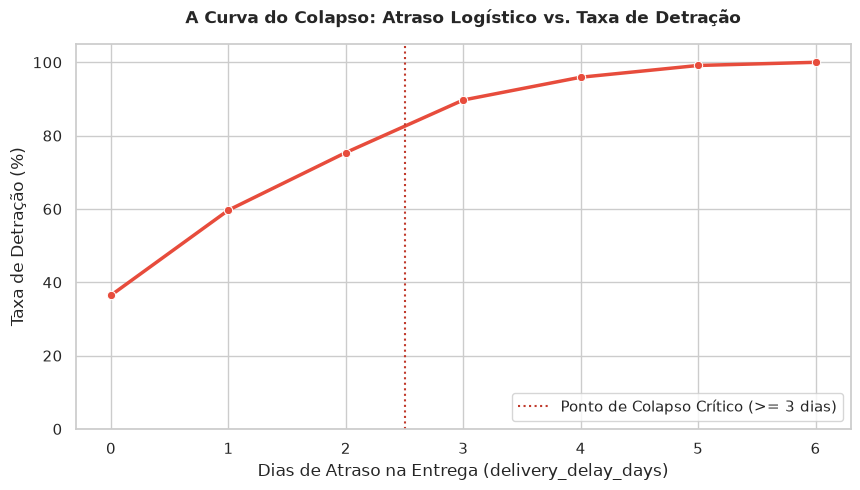

In [72]:
# Mapeamento de Colapso por Atraso Logístico
delay_analysis = df.groupby('delivery_delay_days')['is_detractor'].agg(['count', 'mean'])
delay_analysis['mean'] = delay_analysis['mean'] * 100  # Converte para percentual
delay_analysis.columns = ['Total de Pedidos', 'Taxa de Detração (%)']

print("=== ANÁLISE DE ATRASO LOGÍSTICO VS. TAXA DE DETRAÇÃO ===")
print(delay_analysis.to_string())

# Gráfico de Linha de Colapso
plt.figure(figsize=(10, 5))
ax = sns.lineplot(x=delay_analysis.index, y=delay_analysis['Taxa de Detração (%)'], marker='o', color='#e74c3c', linewidth=2.5)
plt.axvline(x=2.5, color='#c0392b', linestyle=':', label='Ponto de Colapso Crítico (>= 3 dias)')
plt.title("A Curva do Colapso: Atraso Logístico vs. Taxa de Detração", fontweight="bold", pad=15)
plt.xlabel("Dias de Atraso na Entrega (delivery_delay_days)")
plt.ylabel("Taxa de Detração (%)")
plt.ylim(0, 105)
plt.legend()
plt.show()

### Correlação com a variável alvo
Como provamos que a nota de NPS não é normal, o coeficiente de Pearson (que mede correlações lineares e assume normalidade) pode subestimar as relações operacionais reais. Usaremos o coeficiente de **Spearman**, que calcula a associação monotônica entre os postos/ranks das variáveis.

=== MAIORES CORRELAÇÕES DE SPEARMAN COM A TARGET (is_detractor) ===
is_detractor                 1.000000
nps_score                   -0.759508
complaints_count             0.452737
delivery_delay_days          0.420170
customer_service_contacts    0.241635
resolution_time_days         0.150870
order_value                 -0.031963
freight_value                0.028493
customer_tenure_months       0.013254
delivery_time_days          -0.011769
customer_age                -0.009474


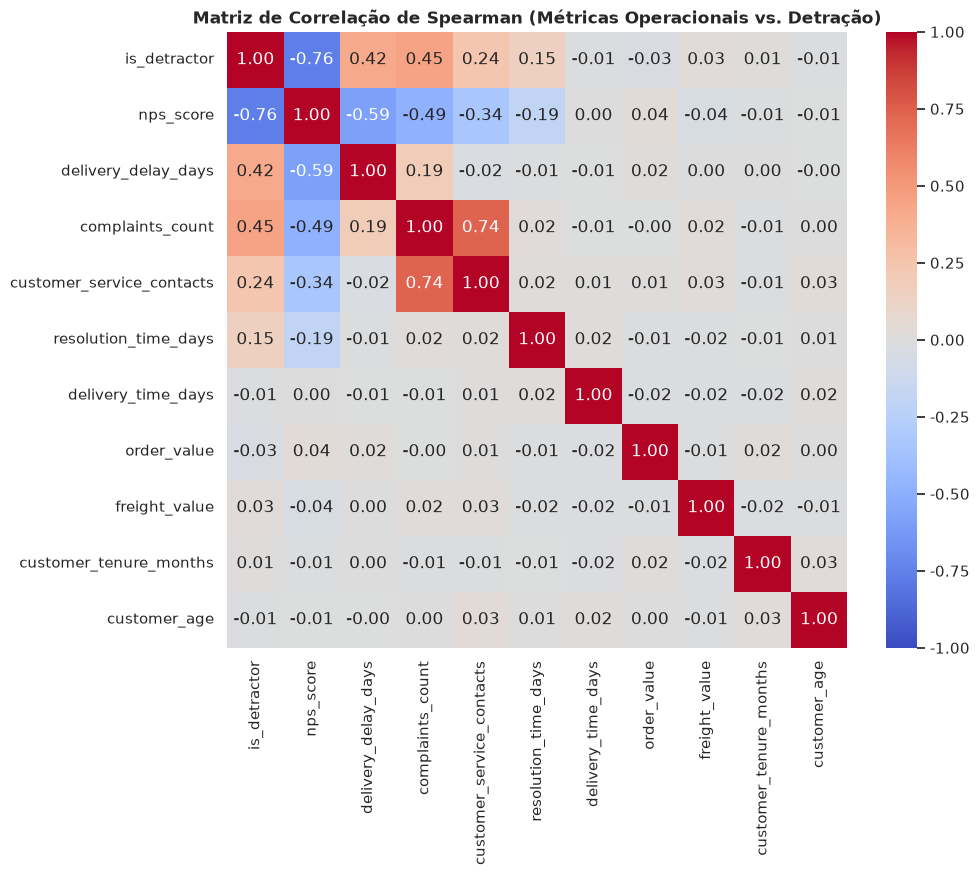

In [73]:
# Correlação de Spearman
numerical_cols = [
    "is_detractor", "nps_score", "delivery_delay_days", "complaints_count",
    "customer_service_contacts", "resolution_time_days", "delivery_time_days",
    "order_value", "freight_value", "customer_tenure_months", "customer_age"
]
numerical_cols = [c for c in numerical_cols if c in df.columns]

spearman_matrix = df[numerical_cols].corr(method='spearman')
print("=== MAIORES CORRELAÇÕES DE SPEARMAN COM A TARGET (is_detractor) ===")
target_corr = spearman_matrix['is_detractor'].sort_values(key=abs, ascending=False)
print(target_corr.to_string())

# Heatmap de Correlações
plt.figure(figsize=(10, 8))
sns.heatmap(spearman_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de Correlação de Spearman (Métricas Operacionais vs. Detração)", fontweight="bold")
plt.show()

### Comparação de Distribuições
O teste de **Mann-Whitney U** é a alternativa não paramétrica para comparar as distribuições de uma variável entre dois grupos independentes (Detratores vs. Não Detratores).

=== TESTE DE MANN-WHITNEY U ===
-> Estatística U: 925586.5
-> p-valor do Teste: 5.9970e-98
-> Média de dias de atraso de Detratores (is_detractor=1): 2.524 dias
-> Média de dias de atraso de Não Detratores (is_detractor=0): 1.197 dias
✓ Conclusão: p-valor < 0.05. Rejeitamos a hipótese nula de que as distribuições são iguais!
  Fica provado com rigor científico de 95% de confiança de que o atraso logístico dos detratores é significativamente superior ao dos não detratores.


/tmp/ipykernel_2644/4284528204.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='is_detractor', y='delivery_delay_days', palette=['#2ecc71', '#e74c3c'], width=0.4, showmeans=True)


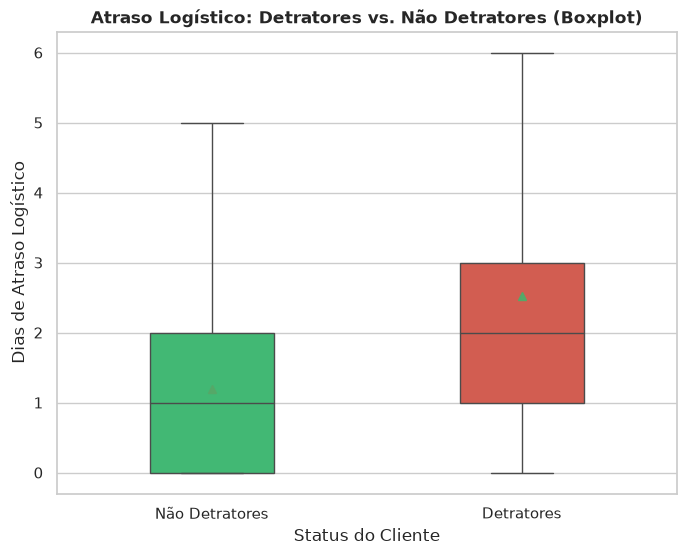

In [74]:
# Teste de Mann-Whitney U para Dias de Atraso
det_delay = df[df['is_detractor'] == 1]['delivery_delay_days']
n_det_delay = df[df['is_detractor'] == 0]['delivery_delay_days']

stat_mw, p_mw = stats.mannwhitneyu(det_delay, n_det_delay, alternative='two-sided')
print("=== TESTE DE MANN-WHITNEY U ===")
print(f"-> Estatística U: {stat_mw:.1f}")
print(f"-> p-valor do Teste: {p_mw:.4e}")
print(f"-> Média de dias de atraso de Detratores (is_detractor=1): {det_delay.mean():.3f} dias")
print(f"-> Média de dias de atraso de Não Detratores (is_detractor=0): {n_det_delay.mean():.3f} dias")

if p_mw < 0.05:
    print("✓ Conclusão: p-valor < 0.05. Rejeitamos a hipótese nula de que as distribuições são iguais!")
    print("  Fica provado com rigor científico de 95% de confiança de que o atraso logístico dos detratores é significativamente superior ao dos não detratores.")
else:
    print("-> Não há diferença estatisticamente significativa entre as distribuições.")

# Boxplot Comparativo de Atraso
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='is_detractor', y='delivery_delay_days', palette=['#2ecc71', '#e74c3c'], width=0.4, showmeans=True)
plt.title("Atraso Logístico: Detratores vs. Não Detratores (Boxplot)", fontweight="bold")
plt.xticks([0, 1], ["Não Detratores", "Detratores"])
plt.xlabel("Status do Cliente")
plt.ylabel("Dias de Atraso Logístico")
plt.show()

### 6. Busca por Vieses na base

In [75]:
# Teste Qui-Quadrado de Independência (Região vs. Detratação)
contingency_region = pd.crosstab(df['customer_region'], df['is_detractor'])
chi2_stat, p_chi2, dof, expected = stats.chi2_contingency(contingency_region)

print("=== TESTE QUI-QUADRADO DE INDEPENDÊNCIA (REGIÃO VS. DETRAÇÃO) ===")
print(f"-> Estatística Qui-Quadrado: {chi2_stat:.4f}")
print(f"-> p-valor do Teste: {p_chi2:.4f}")
print(f"-> Graus de Liberdade: {dof}")
print("-> Tabela de Contingência Observada:")
print(contingency_region)

if p_chi2 >= 0.05:
    print("Não há vieses geográficos nos dados e a detração")
else:
    print("-> Há evidência estatística de dependência geográfica.")

=== TESTE QUI-QUADRADO DE INDEPENDÊNCIA (REGIÃO VS. DETRAÇÃO) ===
-> Estatística Qui-Quadrado: 0.6264
-> p-valor do Teste: 0.9601
-> Graus de Liberdade: 4
-> Tabela de Contingência Observada:
is_detractor       0    1
customer_region          
Centro-Oeste     120  348
Nordeste         126  359
Norte            129  377
Sudeste          132  388
Sul              142  379
Não há vieses geográficos nos dados e a detração


In [76]:
# Teste Qui-Quadrado de Independência (Estrutura do Pedido)
# Cria faixas para avaliar o valor do pedido e do frete em quartis
if 'order_value_q' not in df.columns:
    df['order_value_q'] = pd.qcut(df['order_value'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'], duplicates='drop')
if 'freight_value_q' not in df.columns:
    df['freight_value_q'] = pd.qcut(df['freight_value'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'], duplicates='drop')

for col in ['order_value_q', 'freight_value_q']:
    contingency = pd.crosstab(df[col], df['is_detractor'])
    chi2_stat, p_chi2, dof, expected = stats.chi2_contingency(contingency)
    print(f"=== TESTE QUI-QUADRADO ({col}) ===")
    print(f"-> Estatística Qui-Quadrado: {chi2_stat:.4f}")
    print(f"-> p-valor do Teste: {p_chi2:.4f}")
    print(f"-> Graus de Liberdade: {dof}")
    print(contingency)
    if p_chi2 >= 0.05:
        print("✓ Conclusão: não há evidência estatística de associação significativa entre a faixa e a detração.")
    else:
        print("-> Existe associação estatística relevante entre a faixa e a detração.")
    print()

contingency_installments = pd.crosstab(df['payment_installments'], df['is_detractor'])
chi2_stat, p_chi2, dof, expected = stats.chi2_contingency(contingency_installments)
print("=== TESTE QUI-QUADRADO (payment_installments) ===")
print(f"-> Estatística Qui-Quadrado: {chi2_stat:.4f}")
print(f"-> p-valor do Teste: {p_chi2:.4f}")
print(f"-> Graus de Liberdade: {dof}")
print(contingency_installments)
if p_chi2 >= 0.05:
    print("✓ Conclusão: o número de parcelas não mostra associação estatística relevante com a detração.")
else:
    print("-> Há associação estatística relevante entre parcelas e detração.")

=== TESTE QUI-QUADRADO (order_value_q) ===
-> Estatística Qui-Quadrado: 3.1695
-> p-valor do Teste: 0.3662
-> Graus de Liberdade: 3
is_detractor     0    1
order_value_q          
Q1             150  475
Q2             166  459
Q3             157  468
Q4             176  449
✓ Conclusão: não há evidência estatística de associação significativa entre a faixa e a detração.

=== TESTE QUI-QUADRADO (freight_value_q) ===
-> Estatística Qui-Quadrado: 3.0885
-> p-valor do Teste: 0.3782
-> Graus de Liberdade: 3
is_detractor       0    1
freight_value_q          
Q1               166  459
Q2               174  452
Q3               162  463
Q4               147  477
✓ Conclusão: não há evidência estatística de associação significativa entre a faixa e a detração.

=== TESTE QUI-QUADRADO (payment_installments) ===
-> Estatística Qui-Quadrado: 5.2401
-> p-valor do Teste: 0.8746
-> Graus de Liberdade: 10
is_detractor           0    1
payment_installments         
1                     47  159
2     